In [1]:
from science_jubilee.Machine import Machine
from science_jubilee.tools.Camera import Camera
from science_jubilee.tools.SyringeExtruder import SyringeExtruder
from xarm.wrapper import XArmAPI

from plate_handler import PlateHandler

from pathlib import Path
from datetime import datetime
import threading
import time
import cv2

robot_operation_lock = threading.Lock()

def capture_image(
    camera_index: int = 2,
    output_directory: str = "images/Jubilee",
) -> Path:
    """
    Capture one image from the Jubilee camera.

    Parameters
    ----------
    camera_index:
        OpenCV camera index.

    output_directory:
        Directory in which captured images are saved.

    Returns
    -------
    Path
        Path of the saved image.
    """
    output_path = Path(output_directory)
    output_path.mkdir(parents=True, exist_ok=True)

    camera_capture = cv2.VideoCapture(camera_index)
    camera_capture.set(cv2.CAP_PROP_FRAME_WIDTH,1920)
    camera_capture.set(cv2.CAP_PROP_FRAME_HEIGHT,1080)


    if not camera_capture.isOpened():
        raise RuntimeError(
            f"Could not open camera index {camera_index}."
        )

    try:
        # Discard several initial frames so exposure and white balance can
        # stabilize before the final image is captured.
        for _ in range(20):
            camera_capture.read()

        time.sleep(2)

        success, frame = camera_capture.read()

        if not success or frame is None:
            raise RuntimeError(
                f"Failed to capture an image from camera {camera_index}."
            )

        image_path = (
            output_path
            / f"jubilee_{datetime.now().strftime('%Y%m%d_%H%M%S')}.png"
        )

        if not cv2.imwrite(str(image_path), frame):
            raise RuntimeError(
                f"Failed to save image to {image_path}."
            )

        print(f"Image saved: {image_path}")
        return image_path

    finally:
        camera_capture.release()

def wait_for_jubilee(machine) -> None:
    """Block until Jubilee has finished all queued moves."""
    machine.gcode("M400")

SDK_VERSION: 1.18.5


In [2]:
capture_image(camera_index=0)

2026-08-13 20:46:12.053 Python[59441:18314733] WARNING: AVCaptureDeviceTypeExternal is deprecated for Continuity Cameras. Please use AVCaptureDeviceTypeContinuityCamera and add NSCameraUseContinuityCameraDeviceType to your Info.plist.


Image saved: images/Jubilee/jubilee_20260813_204614.png


PosixPath('images/Jubilee/jubilee_20260813_204614.png')

# Initialize Jubilee

In [12]:
jubilee = Machine(address="192.168.2.2")
# jubilee = Machine(address="localhost") # if running on rasp pi

# register camera tool
camera_tool = Camera(1, "Camera")
jubilee.load_tool(camera_tool)

# register syringe tool
syringe_tool = SyringeExtruder(index=2, name="Syringe", config="10cc_syringe")
jubilee.load_tool(syringe_tool)

0
response in connect:  [True, True, True, True]


home Jubilee if needed

In [ ]:
jubilee.home_all()

# Initialize xArm

In [ ]:
ARM_IP = '192.168.1.205'  # change this to xArm IP
POSITION_FILE = './position.json'
arm = XArmAPI(ARM_IP, do_not_open=True)
arm.connect()
plate_handler = PlateHandler(arm)
plate_handler.initialize()

ROBOT_IP: 192.168.1.205, VERSION: v2.7.0, PROTOCOL: V1, DETAIL: 6,6,XI1304,AC1303,v2.7.0, TYPE1300: [1, 1]
change protocol identifier to 3
[motion_enable], xArm is not ready to move


INFO:origin.print:[motion_enable], xArm is not ready to move


[set_state], xArm is ready to move


INFO:origin.print:[set_state], xArm is ready to move


[SDK][ERROR][2026-08-05 22:09:26][base.py:168] - - [report-socket] socket read timeout


# Register Positions

In [3]:
plate_handler.register_position(
    "Shelf_1",
    save_to_file=True,
    position_file_path=POSITION_FILE,
)

Initial yaw correction: 5.711° | Fine yaw correction: -1.432°
Coarse edge detection after 145.00 mm of positive-Y travel.
Plate edge precisely detected after 143.50 mm of positive-Y travel.
Moved 145.00 mm in negative Y from the detected edge to the plate center.


{'position_id': 'Shelf_1',
 'pose': array([ 4.30068726e+02,  3.69475159e+02,  2.35287003e+02,  1.79877292e+02,
        -3.43947000e-01,  8.54776250e+01]),
 'loaded_plate': None}

In [ ]:
plate_handler.register_position(
    "Shelf_2",
    save_to_file=True,
    position_file_path=POSITION_FILE,
)

In [4]:
plate_handler.register_position(
    "Jubilee",
    save_to_file=True,
    position_file_path=POSITION_FILE,
)

Initial yaw correction: -0.000° | Fine yaw correction: 0.716°
Coarse edge detection after 150.00 mm of positive-Y travel.
Plate edge precisely detected after 149.50 mm of positive-Y travel.
Moved 145.00 mm in negative Y from the detected edge to the plate center.


{'position_id': 'Jubilee',
 'pose': array([ 1.92622177e+02, -4.78248230e+02,  2.42055954e+02, -1.79695092e+02,
         1.73033000e-01, -1.03464260e+02]),
 'loaded_plate': None}

check registered plate_postions

In [4]:
plate_handler.plate_positions

NameError: name 'plate_handler' is not defined

# Associate Plate with Registered Positions

register the plate positions
- plate_1 starts at Shelf_1
- plate_2 starts at Shelf_2
- Jubilee starts empty

In [ ]:
plate_handler.register_plate(
    plate_id="plate_1",
    position_id="Shelf_1",
)

plate_handler.register_plate(
    plate_id="plate_2",
    position_id="Shelf_2",
)

check plate positions

In [ ]:
plate_handler.get_status()

# Example Workflow: Single Gel Inspection Cycle

This cell runs one complete plate inspection cycle for `plate_1`. It records where `plate_1` came from, moves `plate_1` onto Jubilee, uses the camera tool to capture an image, uses the syringe tool to dispense water, moves Jubilee to the xArm pickup clearance position, and returns the plate to its original shelf position.

This is useful for gel swelling inspection: after hydration, repeated images can show swelling or shrinking over time. Before running this manual one-shot cell, check `plate_handler.get_status()` and make sure Jubilee is physically clear.

In [ ]:
# Record plate_1's current position before moving it
plate_1_original_position = plate_handler.get_plate_position("plate_1")

# Move plate_1 from its current position to Jubilee
plate_handler.move_plate(
    plate_id="plate_1",
    destination_position_id="Jubilee",
    move_speed=100,
)


# Move the camera to the capture position and take an image
jubilee.pickup_tool(camera_tool)
jubilee.move_to(x=170, y=106, z=75)
capture_image()
jubilee.park_tool()

# Dispense Water
jubilee.pickup_tool(syringe_tool)
jubilee.move_to(x=170, y=65, z=50)
syringe_tool._dispense(10)
jubilee.park_tool()


# Move to position for arm pickup
jubilee.move_to(x=300, y=10, z=240, wait=True)
wait_for_jubilee(jubilee)


# Return plate_1 to the position it originally came from
plate_handler.move_plate(
    plate_id="plate_1",
    destination_position_id=plate_1_original_position,
    move_speed=100,
)


# Visualize Gel Swelling Time Series

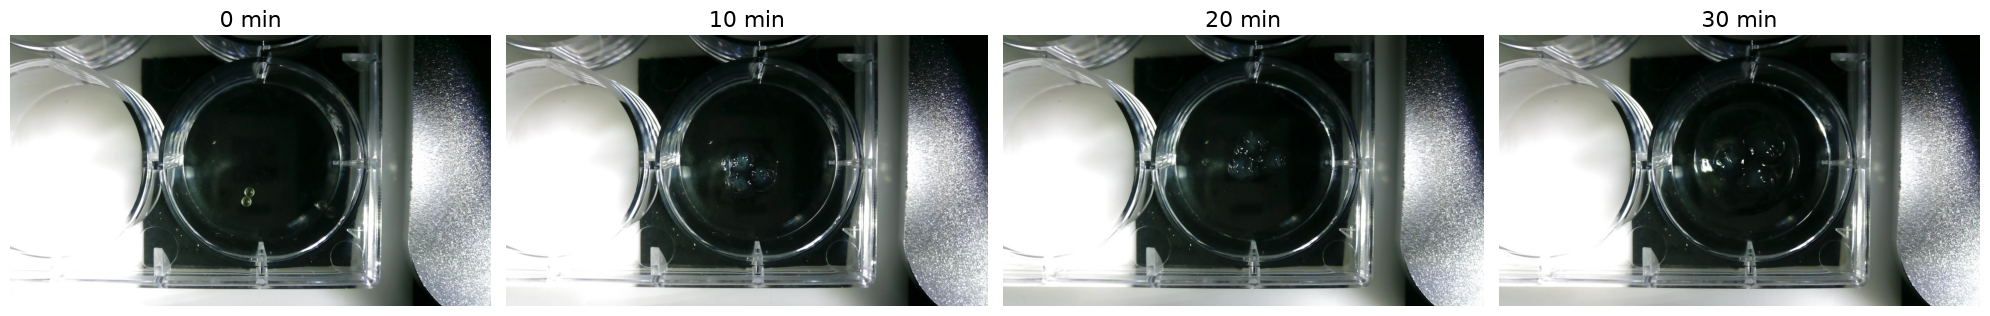

In [16]:
%matplotlib inline
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

time_series_images = [
    ("0 min", Path("images/Jubilee/jubilee_20260813_205239.png")),
    ("10 min", Path("images/Jubilee/jubilee_20260813_210422.png")),
    ("20 min", Path("images/Jubilee/jubilee_20260813_211548.png")),
    ("30 min", Path("images/Jubilee/jubilee_20260813_212636.png")),
]

fig, axes = plt.subplots(1, len(time_series_images), figsize=(20, 5))

for ax, (label, image_path) in zip(axes, time_series_images):
    image = mpimg.imread(image_path)
    ax.imshow(image)
    ax.set_title(label, fontsize=16)
    ax.axis("off")

plt.tight_layout()
plt.show()